In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import numpy as np
import control as ct
from   scipy.linalg import block_diag
from   matplotlib import pyplot as plt

import utils_data

In [2]:
# --! constructors for rf and mechanical mode matrices --!

def make_rf_a(f, q):
    w     = 2 * np.pi * f
    hbw   = w/2/q  # < half-bandwidth of an rf cavity in rad/s

    return np.array([
        [-hbw,     0.],
        [ 0.,    -hbw],
    ])

def make_rf_b(f, q):
    w     = 2 * np.pi * f
    hbw   = w/2/q  # < half-bandwidth of an rf cavity in rad/s

    return np.array([
        [hbw,    0.],
        [0.,    hbw],
    ])

def make_mm_a(f, q):
    """Constructs the matrix A of a single mechanical mode (mm)."""
    w = 2 * np.pi * f
    return np.array([
        [ 0,             1  ],
        [-np.square(w), -w/q],
    ])

def make_mm_b(f):
    """Constructs the matrix B of a single mechanical mode (mm)."""
    w = 2 * np.pi * f
    return np.array([
        [0           ],
        [np.square(w)],
    ])

def make_pzt(bw):
    tau = 1 / (2 * np.pi * bw)
    a = np.array([[-1 / tau]])
    b = np.array([[1 / tau]])
    c = np.array([[1]])
    d = np.array([[0]])

    return ct.ss(a, b, c, d)

def make_mm(f, q):
    a = make_mm_a(f, q)
    b = make_mm_b(f)
    c = np.array([[1, 0]])
    d = np.array([[0]])

    return ct.ss(a, b, c, d)

def cavity_update(t, x, u, param):

    # --! get parameters
    rf_f     = param.get('rf_f')
    rf_q     = param.get('rf_q')
    rf_v     = param.get('rf_v')
    rf_len   = param.get('rf_len')
    mm_f     = param.get('mm_f')
    mm_q     = param.get('mm_q')
    nmm      = len(mm_f)
    mm_k     = param.get('mm_k')

    # --! extract current state of a cavity field: real and imaginary components
    rf_x = np.array(x[:2]).reshape((-1, 1))

    # --! extract current states of all mechanical modes: displacements and velocities
    mm_x = np.array(x[2:]).reshape((-1, 1))

    # --! assemble input to cavity field: real and imaginary parts of a generator voltage
    rf_u = np.array([
        [rf_v[0]],
        [rf_v[1]]
    ])

    # --! compute input to mechanical mode: accelerating field gradient squared
    #
    # --! field gradient has units MV/m, but since we simulate only one cell,
    # --! and the length of one cell is passed as a parameter,
    # --! we need to adjust the total gradient
    rf_grad = np.sqrt(np.square(rf_x[0]) + np.square(rf_x[1]))
    rf_grad = rf_grad * rf_len
    rf_grad = np.square(rf_grad)

    # --! apply control input u to try to suppress the excitation of detuning
    mm_u = mm_k * rf_grad + u

    # --! create rf matrices A and B
    rf_a = make_rf_a(rf_f, rf_q)
    rf_b = make_rf_b(rf_f, rf_q)

    # --! update detuning in rf matrix A
    mm_disp = np.sum([mm_x[2*j] for j in range(nmm)])
    rf_a[0, 1] = -mm_disp
    rf_a[1, 0] =  mm_disp

    # --! assemble mechanical mode matrices: A and B
    mm_a = block_diag(*[make_mm_a(f, q) for f, q in zip(mm_f, mm_q)])
    mm_b = np.concatenate([make_mm_b(f) for f in mm_f], axis=0)

    # --! calculate derivatives
    rf_dx = rf_a @ rf_x + rf_b @ rf_u
    mm_dx = mm_a @ mm_x + mm_b * mm_u

    return np.array([
        *rf_dx.flatten(),
        *mm_dx.flatten(),
    ])

def cavity_output(t, x, u, param):
    mm_x = x[2:]
    nmm  = len(mm_x) // 2
    mm_d = np.sum([mm_x[2*j]     for j in range(nmm)])
    mm_v = np.sum([mm_x[2*j + 1] for j in range(nmm)])
    return np.array([mm_d, mm_v])

# --! wrap an LQR matrix in a nonlinear system object --!

def control_output(t, x, z, param):

    # --! get parameters
    lqr_k = param.get('lqr_k')

    # --! shape controller inputs
    x = np.array(z).reshape((-1, 1))

    return -(lqr_k @ x)

# --! simulate a controlled cavity --!

def sim_cavity_control(t,
                       skip_nsample=50,
                       lqr_r=1.0,
                       mm_f=np.array([40.]), mm_q=np.array([400.]),
                       plotted=True):

    # --! assemble a cavity system as a nonlinear input-output system --!

    cavity_param = {
        'rf_f'     : 1.3e9,
        'rf_q'     : 4.5e7,
        'rf_v'     : [5., 0.],
        'rf_len'   : 0.1615,
        'mm_f'     : mm_f,
        'mm_q'     : mm_q,
        'mm_k'     : 2 * np.pi * 1,
    }

    # --! number of states includes two rf states and the number of mechaical modes times two
    nstate = 2 + 2 * len(cavity_param.get('mm_f'))

    cavity = ct.nlsys(
        cavity_update, cavity_output,
        states=nstate,
        name='cavity', inputs=['pzt'], outputs=['dw', 'ddw'],
        params=cavity_param)

    lqr_plant = make_mm(40, 400)

    # --! normalize plant matrices A and B --!

    det_max = 1.0      # detuning max [rad/s]
    vel_max = 200.0    # velocity max [rad/s^2]
    lqr_max = 10.0     # control max [V]

    norm_x = np.diag([det_max, vel_max])
    norm_u = lqr_max

    norm_a = np.linalg.inv(norm_x) @ lqr_plant.A @ norm_x
    norm_b = np.linalg.inv(norm_x) @ lqr_plant.B * norm_u

    norm_q = np.diag([1.0, 0.1])
    norm_r = np.diag([lqr_r])

    # --! create an LQR --!

    norm_k, _, _ = ct.lqr(norm_a, norm_b, norm_q, norm_r)
    denorm_k = norm_k @ np.linalg.inv(norm_x)

    # --! analyze closed-loop performance --!

    closed_a = lqr_plant.A - lqr_plant.B @ denorm_k
    closed_b = lqr_plant.B
    closed_c = lqr_plant.C
    closed_d = lqr_plant.D

    closed_lqr = ct.ss(closed_a, closed_b, closed_c, closed_d)
    if plotted:
        bw = ct.bandwidth(closed_lqr) / (2 * np.pi)
        print(f'inf > LQR closed-loop bandwidth: {bw:.1f} Hz')

        ct.bode_plot(closed_lqr, Hz=True)

    control_param = {'lqr_k' : denorm_k}

    # --! define controller system
    control = ct.nlsys(
        None, control_output,
        name='control', inputs=['dw', 'ddw'], outputs=['pzt'],
        params=control_param)

    # --! build a closed loop system --!

    cavity_closed = ct.interconnect(
        [control, cavity],
        connections=[
            ['cavity.pzt',  'control.pzt'],
            ['control.dw',  'cavity.dw'],
            ['control.ddw', 'cavity.ddw']
        ],
        outlist=['cavity.dw', 'cavity.ddw', 'control.pzt'],
        outputs=['dw', 'ddw', 'pzt'],
    )

    # --! display input-output response
    resp = ct.input_output_response(cavity_closed, t)
    if plotted:
        resp.plot(plot_inputs=False)

    timeseries_nsample = resp.outputs[0].shape[0] - skip_nsample

    return np.concatenate(
        [
            resp.outputs[0][skip_nsample:].reshape(-1, 1),
            resp.outputs[2][skip_nsample:].reshape(-1, 1),
        ], axis=1).reshape(-1, timeseries_nsample, 2)


inf > LQR closed-loop bandwidth: 68.3 Hz


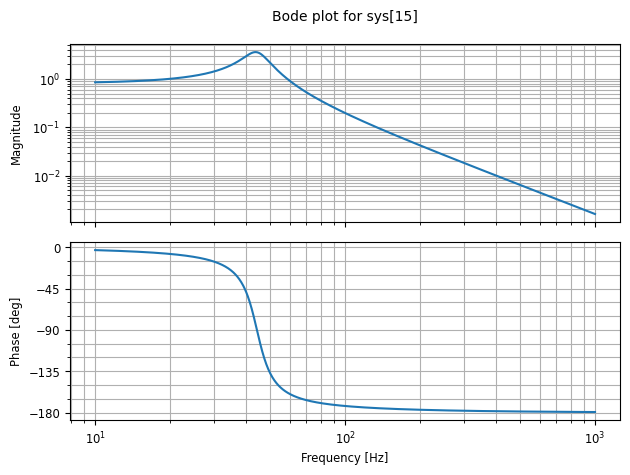

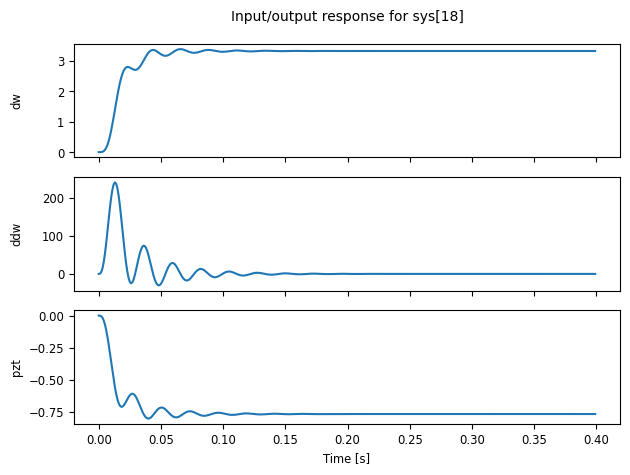

In [5]:
timeseries_nsample = 400
timestep           = 0.001
t = np.arange(0., timeseries_nsample*timestep, timestep)

data = []

data.append(
    sim_cavity_control(
        t, skip_nsample=50,
        lqr_r=1.0,
        mm_f=np.array([40., 20.]), mm_q=np.array([400., 200.]),
        plotted=False))

data.append(
    sim_cavity_control(
        t, skip_nsample=50,
        lqr_r=10.0,
        mm_f=np.array([40.]), mm_q=np.array([400.]),
        plotted=True))

data.append(
    sim_cavity_control(
        t, skip_nsample=50,
        lqr_r=10.0,
        mm_f=np.array([40., 30., 20.]), mm_q=np.array([400., 300., 200.]),
        plotted=False))

In [4]:
# --! save simulated data --!

datasaved = True

if datasaved:
    savedata = np.concatenate(data, axis=0)
    print(f'inf > saved data shape is {savedata.shape}')
    savedir = '../../data/delay'
    utils_data.write_datafile(f'{savedir}/tesla_sim', savedata)

inf > saved data shape is (3, 350, 2)
